# Análise de Correlação: População vs Pontos Críticos Expostos a RNI

Este notebook analisa a relação entre a população de cidades (X) e a quantidade de pontos críticos expostos a RNI (Y).

Estrutura da análise:
1. Geração de dados correlacionados
2. Scatter plot e análise visual
3. Regressão linear simples
4. Análise estatística e R²
5. Gráfico de resíduos
6. Correlação de Pearson

## Importar Bibliotecas Necessárias

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
import seaborn as sns

# Definir estilo dos gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Geração de Dados Correlacionados

Vamos gerar dados sintéticos que simulam a relação entre população de cidades e pontos críticos expostos a RNI.

In [3]:
# Definir seed para reprodutibilidade
np.random.seed(42)

# Número de cidades
n_cidades = 50

# Gerar população das cidades (X) - em milhares de habitantes
X = np.random.uniform(50, 500, n_cidades)  # 50 a 500 mil habitantes

# Gerar pontos críticos (Y) com correlação positiva com X
# Y = a + b*X + erro
a = 10  # intercepto
b = 0.5  # coeficiente angular
erro = np.random.normal(0, 30, n_cidades)  # erro aleatório
Y = a + b * X + erro

# Garantir valores positivos
Y = np.maximum(Y, 0)

# Criar DataFrame
dados = pd.DataFrame({
    'população_mil_hab': X,
    'pontos_criticos': Y
})

print("Primeiras linhas dos dados:")
print(dados.head())
print(f"\nEstatísticas descritivas:")
print(dados.describe())

Primeiras linhas dos dados:
   população_mil_hab  pontos_criticos
0         218.543053       141.425524
1         477.821438       254.051767
2         379.397274       196.229188
3         319.396318       160.665048
4         120.208388        25.748534

Estatísticas descritivas:
       população_mil_hab  pontos_criticos
count          50.000000        50.000000
mean          250.665757       135.244520
std           129.997440        68.794907
min            59.263022        25.748534
25%           132.695148        77.894218
50%           246.221940       141.425325
75%           342.434722       180.205159
max           486.459433       295.438556


---
# PASSO 1: Scatter Plot e Análise Visual da Correlação

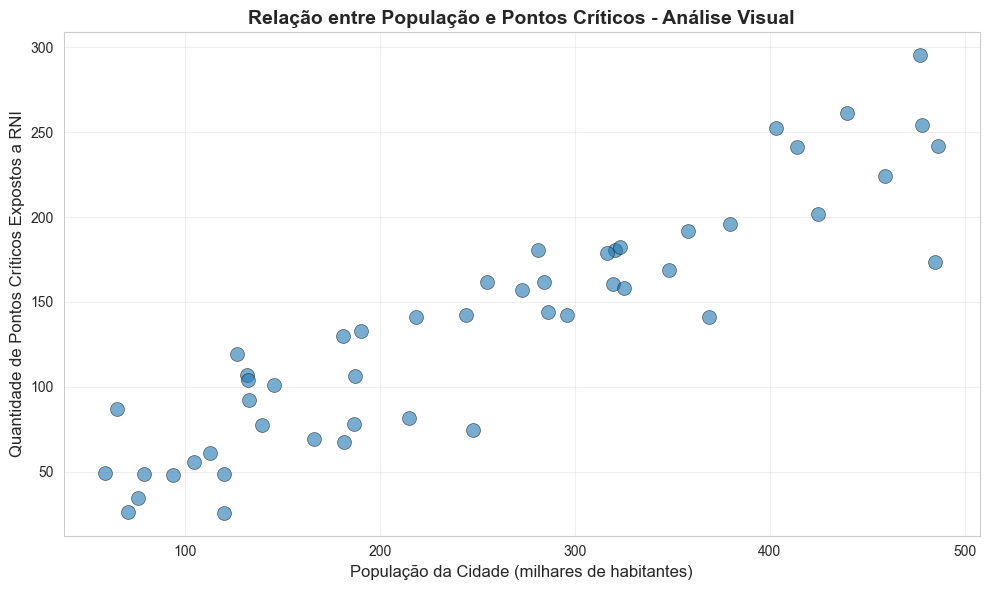

Scatter Plot gerado com sucesso!


In [4]:
# Criar o scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, alpha=0.6, s=100, edgecolors='k', linewidth=0.5)
plt.xlabel('População da Cidade (milhares de habitantes)', fontsize=12)
plt.ylabel('Quantidade de Pontos Críticos Expostos a RNI', fontsize=12)
plt.title('Relação entre População e Pontos Críticos - Análise Visual', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Scatter Plot gerado com sucesso!")

### Discussão do Scatter Plot

Observando o gráfico de dispersão acima:

**Interpretação Visual:**
- Os pontos formam uma **nuvem inclinada para cima** (da esquerda para a direita)
- Isso indica uma **relação positiva** entre população e pontos críticos
- Cidades com maior população tendem a ter mais pontos críticos expostos a RNI
- Existe alguma dispersão dos pontos, indicando que a relação não é perfeita (determinística)

**O padrão observado:**
- À medida que a população aumenta, os pontos críticos também tendem a aumentar
- Não há padrão aleatório - existe uma tendência clara
- A dispersão moderada sugere que existem outros fatores influenciando a quantidade de pontos críticos além apenas da população

---
# PASSO 2: Regressão Linear e Linha de Tendência

In [5]:
# Ajustar modelo de regressão linear
X_reshape = X.reshape(-1, 1)  # Reshape para sklearn
modelo = LinearRegression()
modelo.fit(X_reshape, Y)

# Obter parâmetros
a_estimado = modelo.intercept_
b_estimado = modelo.coef_[0]

# Previsões
Y_pred = modelo.predict(X_reshape)

# Gerar pontos para a linha de tendência
X_linha = np.array([X.min(), X.max()]).reshape(-1, 1)
Y_linha = modelo.predict(X_linha)

print(f"Equação de Regressão: Y = {a_estimado:.2f} + {b_estimado:.4f}*X")
print(f"\nIntercept (a) = {a_estimado:.4f}")
print(f"Coeficiente Angular (b) = {b_estimado:.4f}")

Equação de Regressão: Y = 13.65 + 0.4851*X

Intercept (a) = 13.6455
Coeficiente Angular (b) = 0.4851


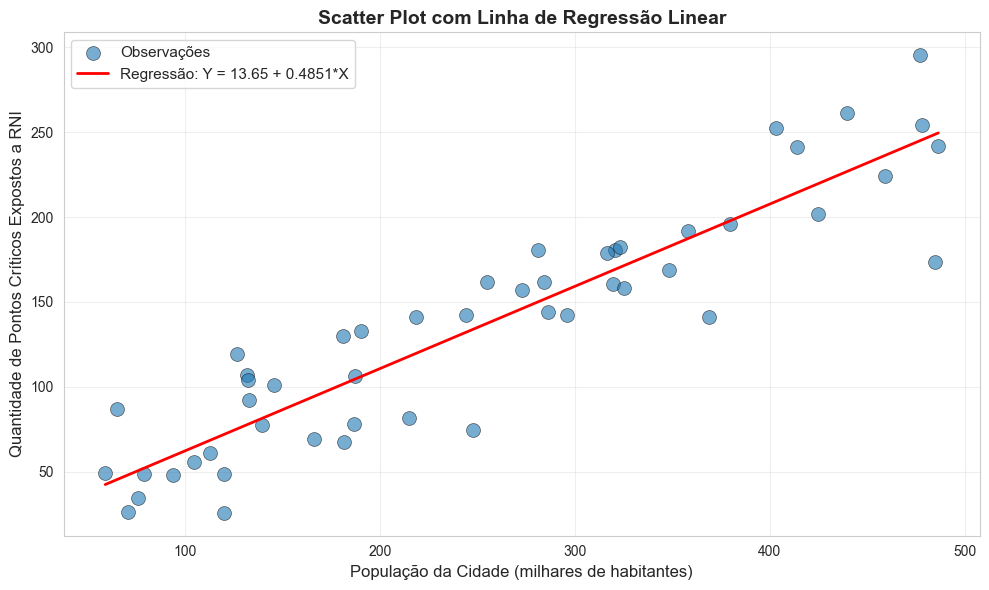

In [6]:
# Plotar scatter plot com linha de regressão
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, alpha=0.6, s=100, edgecolors='k', linewidth=0.5, label='Observações')
plt.plot(X_linha, Y_linha, color='red', linewidth=2, label=f'Regressão: Y = {a_estimado:.2f} + {b_estimado:.4f}*X')
plt.xlabel('População da Cidade (milhares de habitantes)', fontsize=12)
plt.ylabel('Quantidade de Pontos Críticos Expostos a RNI', fontsize=12)
plt.title('Scatter Plot com Linha de Regressão Linear', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Discussão da Regressão Linear

**Equação Ajustada: $Y = a + bX$**

Em que:
- $a$ = intercepto (valor esperado de Y quando X = 0)
- $b$ = coeficiente angular (mudança média em Y para cada unidade de mudança em X)

**Interpretação dos Parâmetros:**

1. **Coeficiente Angular (b):**
   - Como $b > 0$: existe uma **relação positiva** (ver valores calculados na célula anterior)
   - **Cidades maiores tendem a ter mais pontos críticos**
   - Para cada 1.000 habitantes adicionados, espera-se um aumento aproximado de pontos críticos (confira o valor impresso acima)

2. **Intercepto (a):**
   - Valor esperado de pontos críticos quando a população é zero
   - Representa um "baseline" de pontos críticos
   - Ver valor exato impresso na célula Python anterior

3. **Força da Relação:**
   - A inclinação da linha de tendência permite visualizar a força da relação
   - Uma linha mais inclinada indica uma relação mais forte
   - A dispersão dos pontos em torno da linha indica se há outros fatores influenciando

---
# PASSO 3: Análise Estatística - Teste de Significância e R²

In [7]:
# Calcular R-quadrado
R_squared = modelo.score(X_reshape, Y)

# Calcular soma dos quadrados
SS_total = np.sum((Y - np.mean(Y))**2)  # Soma total dos quadrados
SS_residual = np.sum((Y - Y_pred)**2)   # Soma dos quadrados dos resíduos
SS_regression = np.sum((Y_pred - np.mean(Y))**2)  # Soma dos quadrados da regressão

# Graus de liberdade
n = len(Y)
p = 1  # número de variáveis independentes
df_total = n - 1
df_residual = n - p - 1
df_regression = p

# Quadrados médios
MS_regression = SS_regression / df_regression
MS_residual = SS_residual / df_residual

# Estatística F
F_statistic = MS_regression / MS_residual
p_value_F = 1 - stats.f.cdf(F_statistic, df_regression, df_residual)

# Teste t para o coeficiente angular
std_error_b = np.sqrt(MS_residual / np.sum((X - np.mean(X))**2))
t_statistic = b_estimado / std_error_b
p_value_t = 2 * (1 - stats.t.cdf(abs(t_statistic), df_residual))

# Intervalo de confiança para b (95%)
t_critical = stats.t.ppf(0.975, df_residual)
ci_lower = b_estimado - t_critical * std_error_b
ci_upper = b_estimado + t_critical * std_error_b

print("="*60)
print("ANÁLISE ESTATÍSTICA DA REGRESSÃO LINEAR")
print("="*60)
print(f"\nNúmero de observações (n): {n}")
print(f"\n--- COEFICIENTE ANGULAR (b) ---")
print(f"b = {b_estimado:.6f}")
print(f"Erro Padrão de b: {std_error_b:.6f}")
print(f"Estatística t: {t_statistic:.4f}")
print(f"P-value (teste bilateral): {p_value_t:.6f}")
print(f"\nIntervalo de Confiança 95% para b:")
print(f"[{ci_lower:.6f}, {ci_upper:.6f}]")

if p_value_t < 0.05:
    print(f"\n✓ CONCLUSÃO: b é estatisticamente diferente de zero (p < 0.05)")
    print(f"  Existe uma relação linear significativa entre população e pontos críticos.")
else:
    print(f"\n✗ CONCLUSÃO: b NÃO é estatisticamente diferente de zero (p ≥ 0.05)")
    print(f"  Não há evidência de relação linear significativa.")

print(f"\n--- COEFICIENTE DE DETERMINAÇÃO (R²) ---")
print(f"R² = {R_squared:.6f}")
print(f"\nInterpretação:")
print(f"  {R_squared*100:.2f}% da variação em Y é explicada por X")
print(f"  {(1-R_squared)*100:.2f}% da variação em Y é devido a outros fatores")

print(f"\n--- ANÁLISE DE VARIÂNCIA (ANOVA) ---")
print(f"SS Regressão: {SS_regression:.4f}")
print(f"SS Resíduos:  {SS_residual:.4f}")
print(f"SS Total:     {SS_total:.4f}")
print(f"\nMS Regressão: {MS_regression:.4f}")
print(f"MS Resíduos:  {MS_residual:.4f}")
print(f"\nEstatística F: {F_statistic:.4f}")
print(f"P-value F: {p_value_F:.6f}")
print("="*60)

ANÁLISE ESTATÍSTICA DA REGRESSÃO LINEAR

Número de observações (n): 50

--- COEFICIENTE ANGULAR (b) ---
b = 0.485104
Erro Padrão de b: 0.030526
Estatística t: 15.8915
P-value (teste bilateral): 0.000000

Intervalo de Confiança 95% para b:
[0.423728, 0.546481]

✓ CONCLUSÃO: b é estatisticamente diferente de zero (p < 0.05)
  Existe uma relação linear significativa entre população e pontos críticos.

--- COEFICIENTE DE DETERMINAÇÃO (R²) ---
R² = 0.840287

Interpretação:
  84.03% da variação em Y é explicada por X
  15.97% da variação em Y é devido a outros fatores

--- ANÁLISE DE VARIÂNCIA (ANOVA) ---
SS Regressão: 194866.0181
SS Resíduos:  37038.2015
SS Total:     231904.2196

MS Regressão: 194866.0181
MS Resíduos:  771.6292

Estatística F: 252.5384
P-value F: 0.000000


### Discussão dos Resultados Estatísticos

**1. Significância Estatística de b (Teste t):**

- O teste t avalia se o coeficiente angular (b) é estatisticamente diferente de zero
- **Hipótese Nula (H₀):** b = 0 (não há relação linear)
- **Hipótese Alternativa (H₁):** b ≠ 0 (existe relação linear)
- Se p-value < 0.05: rejeitamos H₀ e concluímos que existe relação significativa
- O intervalo de confiança para b nos informa o intervalo onde b provavelmente se encontra

**2. Coeficiente de Determinação (R²):**

- R² indica a **proporção da variação de Y explicada por X**
- Range: 0 a 1 (ou 0% a 100%)
- **Interpretação:**
  - R² próximo de 1: modelo explica bem a variação (forte relação linear)
  - R² próximo de 0: modelo explica pouco (fraca relação linear)
  - O restante da variação (1 - R²) é atribuído a fatores não incluídos no modelo

**3. Análise de Variância (ANOVA):**

- Testa se o modelo de regressão é significativo globalmente
- Estatística F: razão entre variância explicada e variância não explicada
- Um F grande indica que o modelo é significativo

---
# PASSO 4: Análise de Resíduos

In [8]:
# Calcular resíduos
residuos = Y - Y_pred

# Estatísticas dos resíduos
print("Estatísticas dos Resíduos:")
print(f"Média dos resíduos: {np.mean(residuos):.6f} (deve estar próxima de 0)")
print(f"Desvio padrão dos resíduos: {np.std(residuos):.4f}")
print(f"Mínimo: {np.min(residuos):.4f}")
print(f"Máximo: {np.max(residuos):.4f}")

Estatísticas dos Resíduos:
Média dos resíduos: 0.000000 (deve estar próxima de 0)
Desvio padrão dos resíduos: 27.2170
Mínimo: -75.0204
Máximo: 50.3990


<>:7: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:7: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
C:\Users\vicen\AppData\Local\Temp\ipykernel_20008\1246057889.py:7: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  axes[0, 0].set_xlabel('Valores Ajustados ($\hat{Y}$)')


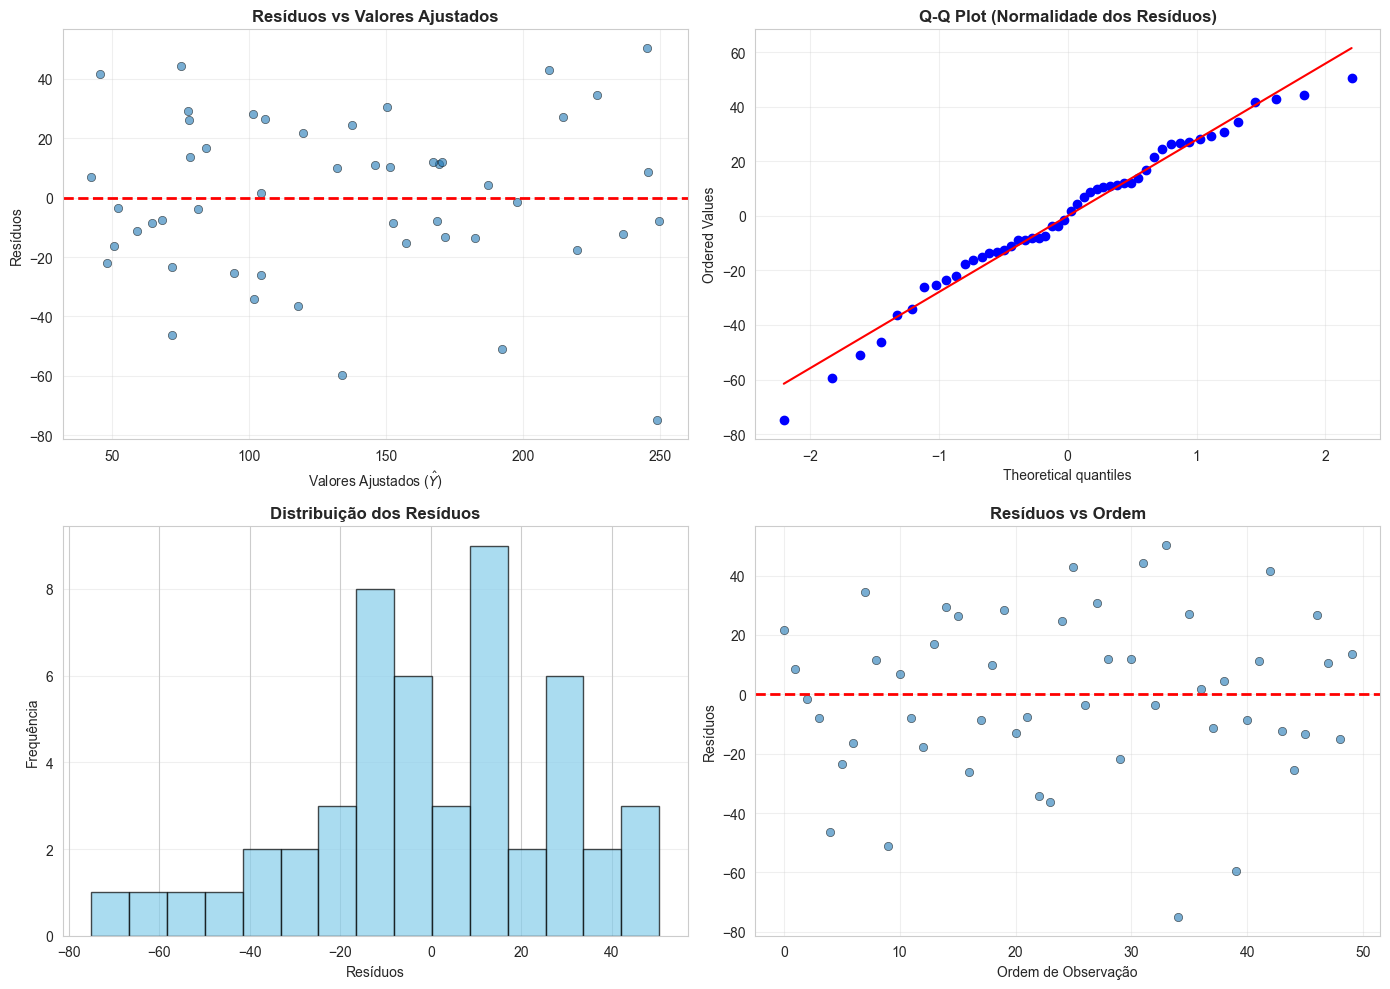

In [9]:
# Criar múltiplos gráficos de resíduos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Resíduos vs Valores Ajustados
axes[0, 0].scatter(Y_pred, residuos, alpha=0.6, edgecolors='k', linewidth=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Valores Ajustados ($\hat{Y}$)')
axes[0, 0].set_ylabel('Resíduos')
axes[0, 0].set_title('Resíduos vs Valores Ajustados', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. QQ-plot (Quantil-Quantil)
stats.probplot(residuos, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Normalidade dos Resíduos)', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histograma dos Resíduos
axes[1, 0].hist(residuos, bins=15, edgecolor='black', alpha=0.7, color='skyblue')
axes[1, 0].set_xlabel('Resíduos')
axes[1, 0].set_ylabel('Frequência')
axes[1, 0].set_title('Distribuição dos Resíduos', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Resíduos vs Ordem de Observação
axes[1, 1].scatter(range(len(residuos)), residuos, alpha=0.6, edgecolors='k', linewidth=0.5)
axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Ordem de Observação')
axes[1, 1].set_ylabel('Resíduos')
axes[1, 1].set_title('Resíduos vs Ordem', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Discussão da Análise de Resíduos

**O que são resíduos?**

Resíduo = $Y_{observado} - Y_{estimado}$

Os resíduos representam a diferença entre os valores observados e os valores preditos pelo modelo.

**Interpretação dos Gráficos de Resíduos:**

1. **Resíduos vs Valores Ajustados:**
   - Esperado: padrão aleatório, sem nenhuma tendência
   - Se houver padrão: a relação pode não ser linear
   - Se a dispersão aumentar com X: pode haver heterocedasticidade

2. **Q-Q Plot (Normalidade):**
   - Verifica se os resíduos seguem uma distribuição normal
   - Esperado: pontos próximos à linha diagonal
   - Desvios nas caudas indicam caudas pesadas ou leves

3. **Histograma dos Resíduos:**
   - Esperado: distribuição aproximadamente simétrica (forma de sino)
   - Indica se há desvio da normalidade visualmente

4. **Resíduos vs Ordem:**
   - Verifica autocorrelação nos resíduos
   - Esperado: distribuição aleatória ao longo da sequência
   - Padrão indica correlação com o tempo ou ordem dos dados

**Conclusão sobre a Adequação do Modelo Linear:**

- Se os resíduos forem aleatórios e normalmente distribuídos: **o modelo linear é apropriado**
- Se houver padrão evidente: **a relação pode não ser linear** ou há variáveis omitidas

---
# PASSO 5: Correlação de Pearson

## Formulação Matemática

A correlação de Pearson é a medida clássica para quantificar a relação linear entre duas variáveis contínuas.

**Fórmula:**

$$r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2} \cdot \sqrt{\sum_{i=1}^{n} (y_i - \bar{y})^2}}$$

Onde:
- $x_i, y_i$ = valores observados das variáveis X e Y
- $\bar{x}, \bar{y}$ = médias de X e Y
- $n$ = número de observações

**Numerador:** Covariância entre X e Y (mede como X e Y variam conjuntamente)

**Denominador:** Produto dos desvios padrão (normaliza a covariância para o intervalo [-1, 1])

**Propriedades:**
- Range: -1 a +1
- r > 0: correlação positiva (ambas aumentam juntas)
- r < 0: correlação negativa (uma aumenta, outra diminui)
- r = 0: sem correlação linear

In [10]:
# Implementar manualmente a correlação de Pearson

# Passo 1: Calcular médias
x_media = np.mean(X)
y_media = np.mean(Y)

# Passo 2: Calcular desvios
desvios_x = X - x_media
desvios_y = Y - y_media

# Passo 3: Calcular covariância (numerador)
covariancia = np.sum(desvios_x * desvios_y)

# Passo 4: Calcular denominador
soma_quadrados_x = np.sum(desvios_x**2)
soma_quadrados_y = np.sum(desvios_y**2)
denominador = np.sqrt(soma_quadrados_x * soma_quadrados_y)

# Passo 5: Calcular correlação
r_manual = covariancia / denominador

print("="*60)
print("CORRELAÇÃO DE PEARSON - CÁLCULO MANUAL")
print("="*60)
print(f"\nMédia de X (população): {x_media:.4f}")
print(f"Média de Y (pontos críticos): {y_media:.4f}")
print(f"\nCovariância: {covariancia:.4f}")
print(f"Soma de quadrados de X: {soma_quadrados_x:.4f}")
print(f"Soma de quadrados de Y: {soma_quadrados_y:.4f}")
print(f"\nNumerador (Covariância): {covariancia:.4f}")
print(f"Denominador: {denominador:.4f}")
print(f"\nCorrelação de Pearson (r): {r_manual:.6f}")
print("="*60)

CORRELAÇÃO DE PEARSON - CÁLCULO MANUAL

Média de X (população): 250.6658
Média de Y (pontos críticos): 135.2445

Covariância: 401699.1353
Soma de quadrados de X: 828067.3915
Soma de quadrados de Y: 231904.2196

Numerador (Covariância): 401699.1353
Denominador: 438214.9270

Correlação de Pearson (r): 0.916672


In [11]:
# Validar com scipy
r_scipy, p_value_pearson = stats.pearsonr(X, Y)

print(f"\nValidação usando scipy:")
print(f"Correlação de Pearson (scipy): {r_scipy:.6f}")
print(f"P-value: {p_value_pearson:.6f}")
print(f"\nDiferença entre cálculo manual e scipy: {abs(r_manual - r_scipy):.10f}")


Validação usando scipy:
Correlação de Pearson (scipy): 0.916672
P-value: 0.000000

Diferença entre cálculo manual e scipy: 0.0000000000


In [12]:
# Relação entre correlação de Pearson e regressão
print("\n" + "="*60)
print("RELAÇÃO ENTRE CORRELAÇÃO E REGRESSÃO")
print("="*60)

# Desvios padrão
std_x = np.std(X, ddof=1)  # ddof=1 para amostra
std_y = np.std(Y, ddof=1)

# Correlação pode ser expressa em função do coeficiente angular
# r = b * (std_x / std_y)
r_calculado = b_estimado * (std_x / std_y)

print(f"\nDesvio padrão de X: {std_x:.4f}")
print(f"Desvio padrão de Y: {std_y:.4f}")
print(f"Coeficiente angular (b): {b_estimado:.6f}")
print(f"\nr = b * (std_x / std_y) = {r_calculado:.6f}")
print(f"r calculado diretamente: {r_manual:.6f}")
print(f"\nAlém disso: r² = R² de correlação")
print(f"r² = {r_manual**2:.6f}")
print(f"R² = {R_squared:.6f}")
print("="*60)


RELAÇÃO ENTRE CORRELAÇÃO E REGRESSÃO

Desvio padrão de X: 129.9974
Desvio padrão de Y: 68.7949
Coeficiente angular (b): 0.485104

r = b * (std_x / std_y) = 0.916672
r calculado diretamente: 0.916672

Além disso: r² = R² de correlação
r² = 0.840287
R² = 0.840287


## Interpretação da Correlação de Pearson

| Valor de r | Interpretação |
|:---:|:---|
| 0.7 a 1.0 | **Correlação forte positiva** - Relação linear forte e positiva |
| 0.3 a 0.7 | **Correlação moderada** - Existe relação linear, mas com dispersão notável |
| 0.0 a 0.3 | **Correlação fraca** - Relação linear fraca ou praticamente ausente |
| 0 | **Sem correlação** - Não há relação linear detectável |
| -0.3 a -1.0 | **Valores negativos** - Relação inversa (uma aumenta, outra diminui) |

**Observações Importantes:**

1. **Correlação vs Causalidade:**
   - Uma correlação forte NÃO implica relação causal
   - Correlação apenas descreve associação linear entre variáveis

2. **Significância Estatística:**
   - O p-value indica se a correlação é significativamente diferente de zero
   - p < 0.05: correlação é estatisticamente significativa
   - Uma correlação pequena pode ser significativa com amostra grande

3. **Relação com R²:**
   - R² = r²
   - Representa a proporção de variância compartilhada entre variáveis

4. **Limitações:**
   - Pearson mede apenas relações lineares
   - Sensível a outliers
   - Requer que dados sejam contínuos

## Conclusão e Resumo

In [13]:
print("\n" + "="*70)
print(" "*15 + "RESUMO GERAL DA ANÁLISE DE CORRELAÇÃO")
print("="*70)

print(f"\n1. CORRELAÇÃO DE PEARSON:")
print(f"   r = {r_manual:.6f}")
print(f"   p-value = {p_value_pearson:.6f}")

# Classificar correlação
r_abs = abs(r_manual)
if r_abs >= 0.7:
    interpretacao = "FORTE"
elif r_abs >= 0.3:
    interpretacao = "MODERADA"
elif r_abs >= 0:
    interpretacao = "FRACA"
else:
    interpretacao = "NENHUMA"

direcao = "positiva" if r_manual > 0 else "negativa"
print(f"   Classificação: Correlação {interpretacao} {direcao}")

if p_value_pearson < 0.05:
    print(f"   ✓ Estatisticamente significativa (p < 0.05)")
else:
    print(f"   ✗ Não é estatisticamente significativa (p ≥ 0.05)")

print(f"\n2. REGRESSÃO LINEAR:")
print(f"   Equação: Y = {a_estimado:.4f} + {b_estimado:.6f}*X")
print(f"   Coeficiente angular (b) p-value = {p_value_t:.6f}")
if p_value_t < 0.05:
    print(f"   ✓ Coeficiente estatisticamente significativo")
else:
    print(f"   ✗ Coeficiente não é estatisticamente significativo")

print(f"\n3. QUALIDADE DO AJUSTE:")
print(f"   R² = {R_squared:.6f}")
print(f"   {R_squared*100:.2f}% da variação em Y é explicada por X")
print(f"   {(1-R_squared)*100:.2f}% é devido a outros fatores")

print(f"\n4. DADOS UTILIZADOS:")
print(f"   Número de observações: {n}")
print(f"   População - Média: {x_media:.2f}, Desvio padrão: {std_x:.2f}")
print(f"   Pontos críticos - Média: {y_media:.2f}, Desvio padrão: {std_y:.2f}")

print(f"\n5. CONCLUSÃO FINAL:")
if abs(r_manual) >= 0.3 and p_value_pearson < 0.05:
    print(f"   ✓ EXISTE CORRELAÇÃO SIGNIFICATIVA entre população e pontos críticos")
    if r_manual > 0:
        print(f"   ✓ A relação é POSITIVA: cidades maiores tendem a ter mais pontos críticos")
    else:
        print(f"   ✓ A relação é NEGATIVA: cidades menores tendem a ter mais pontos críticos")
else:
    print(f"   ✗ Não há evidência de correlação significativa entre as variáveis")

print("\n" + "="*70)


               RESUMO GERAL DA ANÁLISE DE CORRELAÇÃO

1. CORRELAÇÃO DE PEARSON:
   r = 0.916672
   p-value = 0.000000
   Classificação: Correlação FORTE positiva
   ✓ Estatisticamente significativa (p < 0.05)

2. REGRESSÃO LINEAR:
   Equação: Y = 13.6455 + 0.485104*X
   Coeficiente angular (b) p-value = 0.000000
   ✓ Coeficiente estatisticamente significativo

3. QUALIDADE DO AJUSTE:
   R² = 0.840287
   84.03% da variação em Y é explicada por X
   15.97% é devido a outros fatores

4. DADOS UTILIZADOS:
   Número de observações: 50
   População - Média: 250.67, Desvio padrão: 130.00
   Pontos críticos - Média: 135.24, Desvio padrão: 68.79

5. CONCLUSÃO FINAL:
   ✓ EXISTE CORRELAÇÃO SIGNIFICATIVA entre população e pontos críticos
   ✓ A relação é POSITIVA: cidades maiores tendem a ter mais pontos críticos



---
# APÊNDICE: Análise com Amostras Pequenas (5 Pontos)

## O Dilema do Tamanho da Amostra: Será que funciona com poucos dados?

Uma pergunta natural surge: **"E se tivéssemos apenas 5 observações em vez de 50?"**

Esta é uma questão crítica em estatística porque o tamanho da amostra (n) tem um impacto profundo na confiabilidade dos resultados.

### Por que o tamanho da amostra é importante?

#### 1. **Graus de Liberdade (df)**

O número de graus de liberdade em regressão linear é: $df = n - 2$

Onde:
- Com n = 50: df = 48 (muita liberdade para estimar a verdadeira relação)
- Com n = 5: df = 3 (muito poucas observações para confiar no modelo)

**Impacto direto:** O teste estatístico (teste t) usa df para calcular se b é significativo. Com df pequeno, o t crítico cresce, tornando mais difícil rejeitar H₀.

#### 2. **Erro Padrão da Regressão Aumenta**

O erro padrão de b é: $SE_b = \sqrt{\frac{\text{Variância Residual}}{\sum(x_i - \bar{x})^2}}$

Com poucos pontos:
- Estimativas de variância são menos confiáveis
- O denominador é menor (menos dispersão em X)
- Resultado: SE_b fica muito grande

#### 3. **Correlação Spureia (Enganosa)**

Uma correlação falsamente alta pode surgir com poucos pontos. Por exemplo:
- Com 2 pontos: sempre r = ±1 (correlação perfeita!) - mas não significa nada!
- Com 3-5 pontos: correlações podem ser altas por puro acaso, não por relação verdadeira

#### 4. **Indeterminação vs Determinação**

Com 2 pontos:
- Ajusta uma linha de regressão perfeitamente (R² = 1)
- Mas não há resíduo para testar (0 graus de liberdade)

Com 3 pontos:
- Possível testar significância (1 grau de liberdade)
- Mas os intervalos de confiança são ENORMES

Com 5 pontos:
- Tecnicamente possível
- Mas resultados muito instáveis e pouco confiáveis

### Exemplo: O que mudaria com 5 pontos?

Suponha que selecionássemos apenas 5 cidades de nossa base de 50:

**Cenário 1: 5 pontos bem selecionados**
- Pode resultar em uma correlação bem alta (enganosa)
- P-value pode ser enganosamente baixo
- R² pode parecer promissor
- MAS: Muito sensível a outliers

**Cenário 2: 5 pontos mal selecionados**
- Correlação baixa (mesmo que exista verdadeira correlação)
- P-value alto (erro tipo II: não detectar correlação real)
- R² baixo
- Conclusão errônea: "não há correlação" (quando há!)

**Variabilidade:** Se repetíssemos a amostragem aleatória 1000 vezes:
- Com n=50: resultados relativamente estáveis
- Com n=5: resultados MUITO variáveis, r poderia variar de -0.8 a +0.8!

### Recomendações Práticas

| Aspecto | Recomendação |
|:---|:---|
| **Tamanho mínimo de amostra** | n ≥ 30 para testes de significância (regra prática) |
| **Mínimo absoluto** | n ≥ 3 (para calcular regressão linear) |
| **Ideal para confiança alta** | n ≥ 100 ou mais (especialmente em pesquisa) |
| **Com n = 5** | Descritivo apenas, SEM testes estatísticos formais |
| **Com n < 30** | Use cuidado extremo, considere métodos não-paramétricos |

### Fórmula do Erro Padrão em Função de n

Para uma regressão linear com dados similares:

$$SE_b \propto \frac{1}{\sqrt{n}}$$

Isso significa:
- Reduzir n de 50 para 5 (10x menor):
- SE_b aumenta por √10 ≈ 3.16 vezes
- Intervalo de confiança fica 3x mais largo!

### Conclusão sobre Amostras Pequenas

**PODE usar 5 pontos para:**
- ✓ Análise exploratória e descritiva
- ✓ Gerar hipóteses (não testá-las)
- ✓ Visualizar relações potenciais
- ✓ Casos onde é impossível coletar mais dados

**NÃO deve usar 5 pontos para:**
- ✗ Testar significância estatística (p-values não são confiáveis)
- ✗ Fazer inferências sobre a população
- ✗ Tomar decisões críticas baseadas em p < 0.05
- ✗ Publicar como resultado definitivo

**Lei de Ouro:** Sempre mencione o tamanho da amostra e suas limitações!

Com dados reais sobre cidades e pontos críticos, recomenda-se:
- **Mínimo 30+ cidades** para correlação confiável
- **50+ cidades** para análise robusta
- **100+ cidades** para alto nível de confiança